In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

data = np.loadtxt("dist.xvg", comments=['#', '@'])
print(data)

[[0.000e+00 1.330e-01]
 [1.000e-03 1.330e-01]
 [2.000e-03 1.330e-01]
 ...
 [1.998e+00 1.320e-01]
 [1.999e+00 1.320e-01]
 [2.000e+00 1.330e-01]]


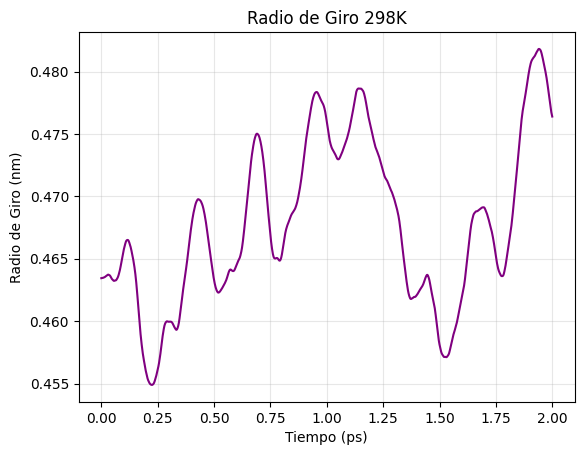

In [3]:
data = np.loadtxt("gyrate.xvg", comments=['#', '@'])
plt.plot(data[:, 0], data[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Radio de Giro (nm)") 
plt.title("Radio de Giro 298K") 
plt.grid(alpha=0.3)
plt.show()

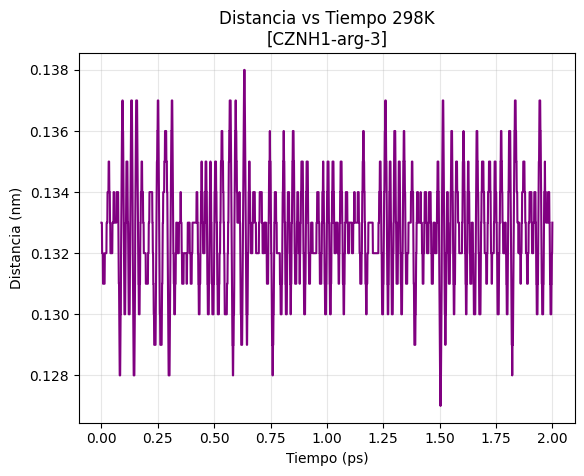

In [4]:
data = np.loadtxt("dist.xvg", comments=['#', '@'])
plt.plot(data[:, 0], data[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Distancia (nm)") 
#plt.title("Distancia vs Tiempo 298K")
plt.title("Distancia vs Tiempo 298K\n" + r"[CZNH1-arg-3]") 
plt.grid(alpha=0.3)
plt.show()

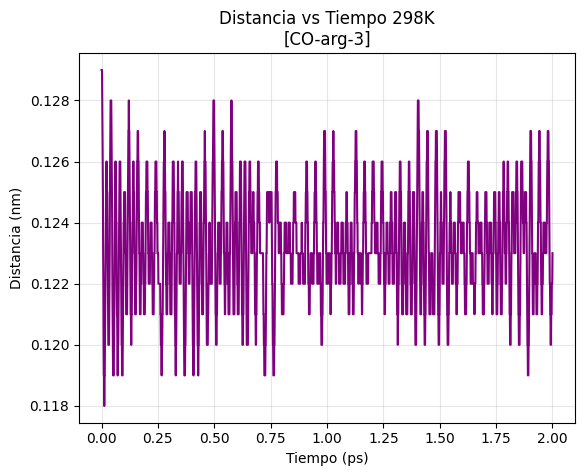

In [5]:
data2 = np.loadtxt("#dist.xvg.1#", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)")  
plt.ylabel("Distancia (nm)") 
plt.title("Distancia vs Tiempo 298K\n" + r"[CO-arg-3]") 
plt.grid(alpha=0.3)
plt.show()

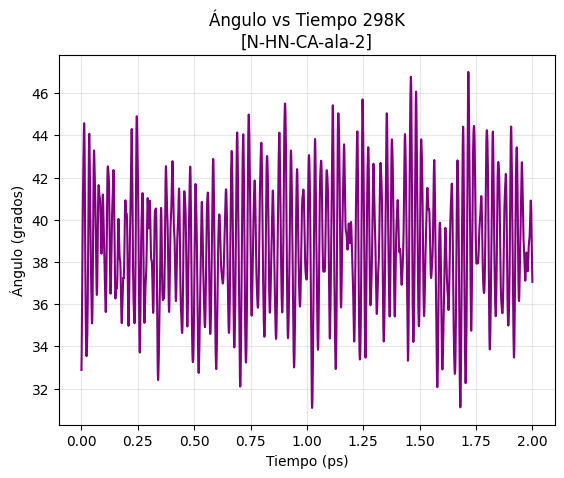

In [6]:
data2 = np.loadtxt("angaver.xvg", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Ángulo (grados)") 
plt.title("Ángulo vs Tiempo 298K\n" + r"[N-HN-CA-ala-2]") 
plt.grid(alpha=0.3)
plt.show()


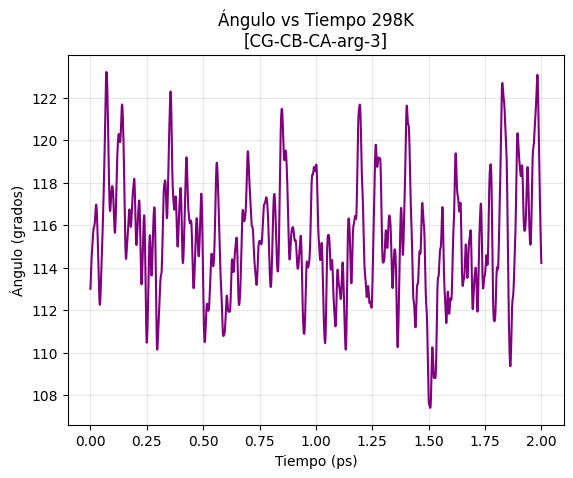

In [7]:
data2 = np.loadtxt("#angaver.xvg.1#", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Ángulo (grados)") 
plt.title("Ángulo vs Tiempo 298K\n" + r"[CG-CB-CA-arg-3]") 
plt.grid(alpha=0.3)
plt.show()

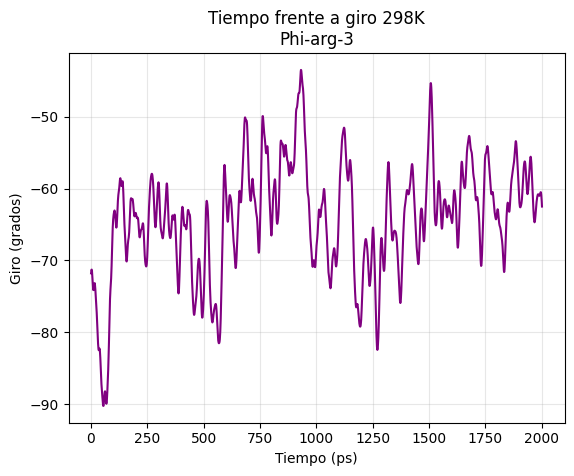

In [8]:
data2 = np.loadtxt("phi-arg-3.dat", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Giro (grados)") 
plt.title("Tiempo frente a giro 298K\n" + r"Phi-arg-3") 
plt.grid(alpha=0.3)
plt.show()


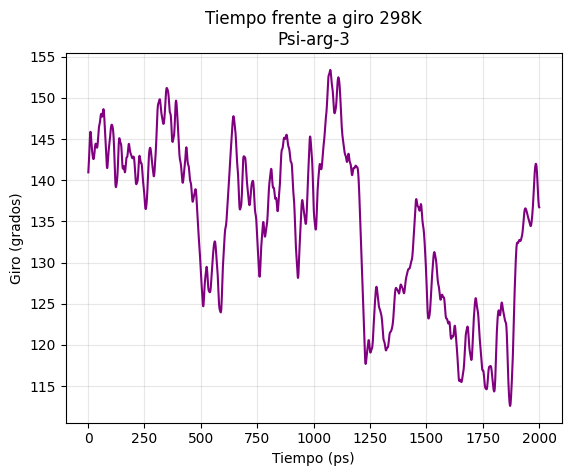

In [9]:
data2 = np.loadtxt("psi-arg-3.dat", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Giro (grados)") 
plt.title("Tiempo frente a giro 298K\n" + r"Psi-arg-3") 
plt.grid(alpha=0.3)
plt.show()

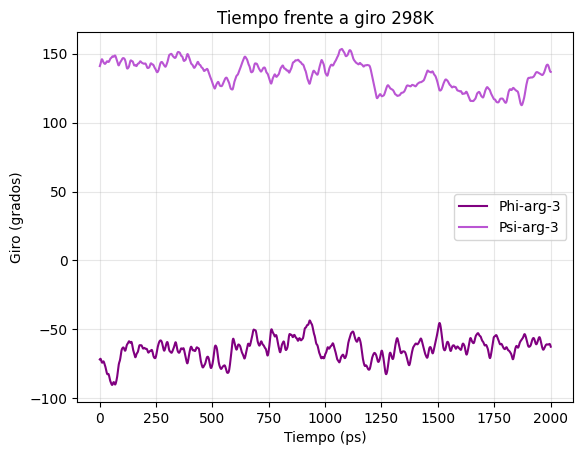

In [10]:
data2 = np.loadtxt("arg-3.dat", comments=['#', '@'])
plt.plot(data2[:, 0], data2[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-', label="Phi-arg-3")
plt.plot(data2[:, 0], data2[:, 2], color=mcolors.CSS4_COLORS['mediumorchid'], linestyle='-', label="Psi-arg-3")
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Giro (grados)") 
plt.title("Tiempo frente a giro 298K") 
plt.legend()
plt.grid(alpha=0.3)
plt.show()

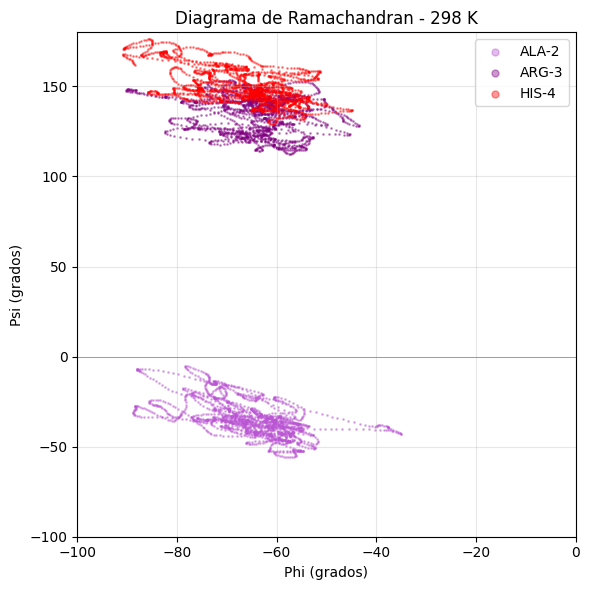

In [11]:
phi = []
psi = []
residuos = []


with open('rama.xvg', 'r') as f:
    for line in f:
        # Saltar líneas de comentario
        if line.startswith('#') or line.startswith('@'):
            continue
        cols = line.split()
        if len(cols) >= 3:
            phi.append(float(cols[0]))
            psi.append(float(cols[1]))
            residuos.append(cols[2])

phi = np.array(phi)
psi = np.array(psi)
residuos = np.array(residuos)

# Plot general
plt.figure(figsize=(6,6))
# Por residuo con colores personalizados
colores = {
    'ALA-2': 'mediumorchid',
    'ARG-3': 'purple',
    'HIS-4': 'r'
}

for res in np.unique(residuos):
    mask = residuos == res
    plt.scatter(phi[mask], psi[mask], s=1, alpha=0.4, 
                color=colores.get(res, 'gray'), label=res)
plt.xlabel('Phi (grados)')
plt.ylabel('Psi (grados)')
plt.title('Diagrama de Ramachandran - 298 K')
plt.xlim(-100, 0)
plt.ylim(-100, 180)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()

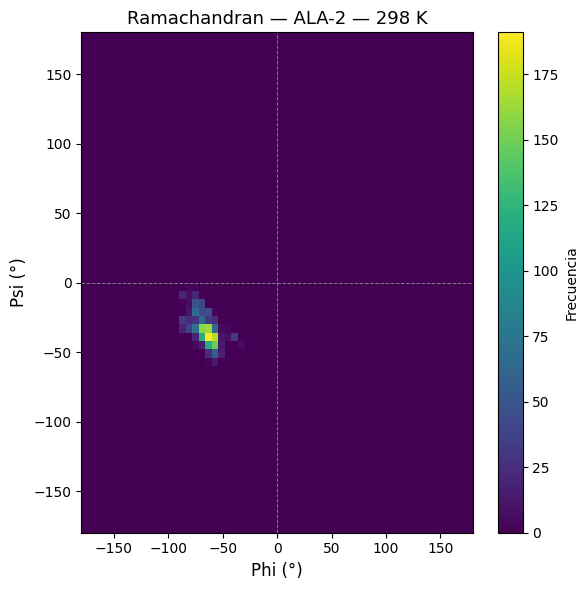

In [12]:
mask = residuos == 'ALA-2'
phi_res = phi[mask]
psi_res = psi[mask]

fig, ax = plt.subplots(figsize=(6, 6))

h = ax.hist2d(phi_res, psi_res,
              bins=60,
              range=[[-180, 180], [-180, 180]],
              cmap='viridis')

plt.colorbar(h[3], ax=ax, label='Frecuencia')
ax.set_xlabel('Phi (°)', fontsize=12)
ax.set_ylabel('Psi (°)', fontsize=12)
ax.set_title(f'Ramachandran — ALA-2 — 298 K', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')

plt.tight_layout()
plt.show()

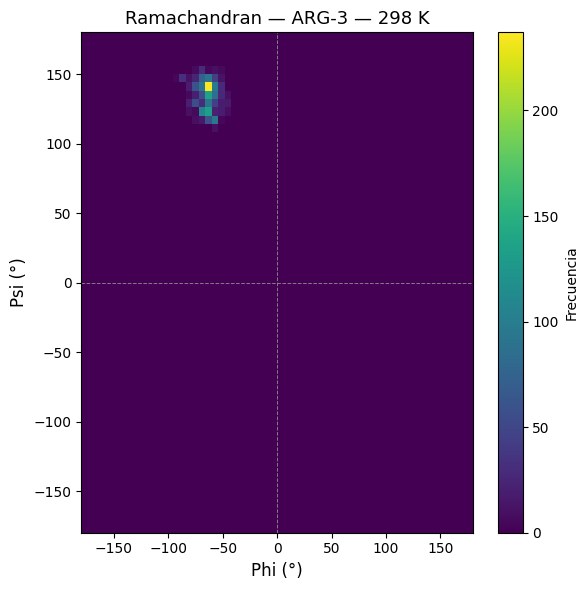

In [ ]:
mask = residuos == 'ARG-3'
phi_res = phi[mask]
psi_res = psi[mask]

fig, ax = plt.subplots(figsize=(6, 6))

h = ax.hist2d(phi_res, psi_res,
              bins=60,
              range=[[-180, 180], [-180, 180]],
              cmap='viridis')

plt.colorbar(h[3], ax=ax, label='Frecuencia')
ax.set_xlabel('Phi (°)', fontsize=12)
ax.set_ylabel('Psi (°)', fontsize=12)
ax.set_title(f'Ramachandran — ARG-3 — 298 K', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')

plt.tight_layout()
plt.show()

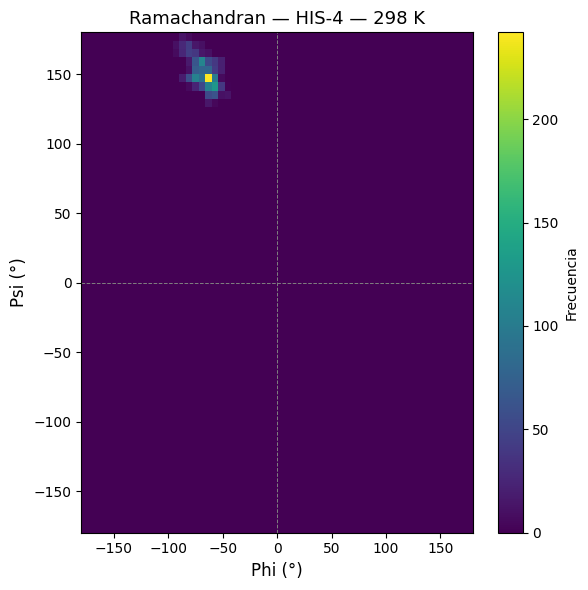

In [ ]:
mask = residuos == 'HIS-4'
phi_res = phi[mask]
psi_res = psi[mask]

fig, ax = plt.subplots(figsize=(6, 6))

h = ax.hist2d(phi_res, psi_res,
              bins=60,
              range=[[-180, 180], [-180, 180]],
              cmap='viridis')

plt.colorbar(h[3], ax=ax, label='Frecuencia')
ax.set_xlabel('Phi (°)', fontsize=12)
ax.set_ylabel('Psi (°)', fontsize=12)
ax.set_title(f'Ramachandran — HIS-4 — 298 K', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')

plt.tight_layout()
plt.show()

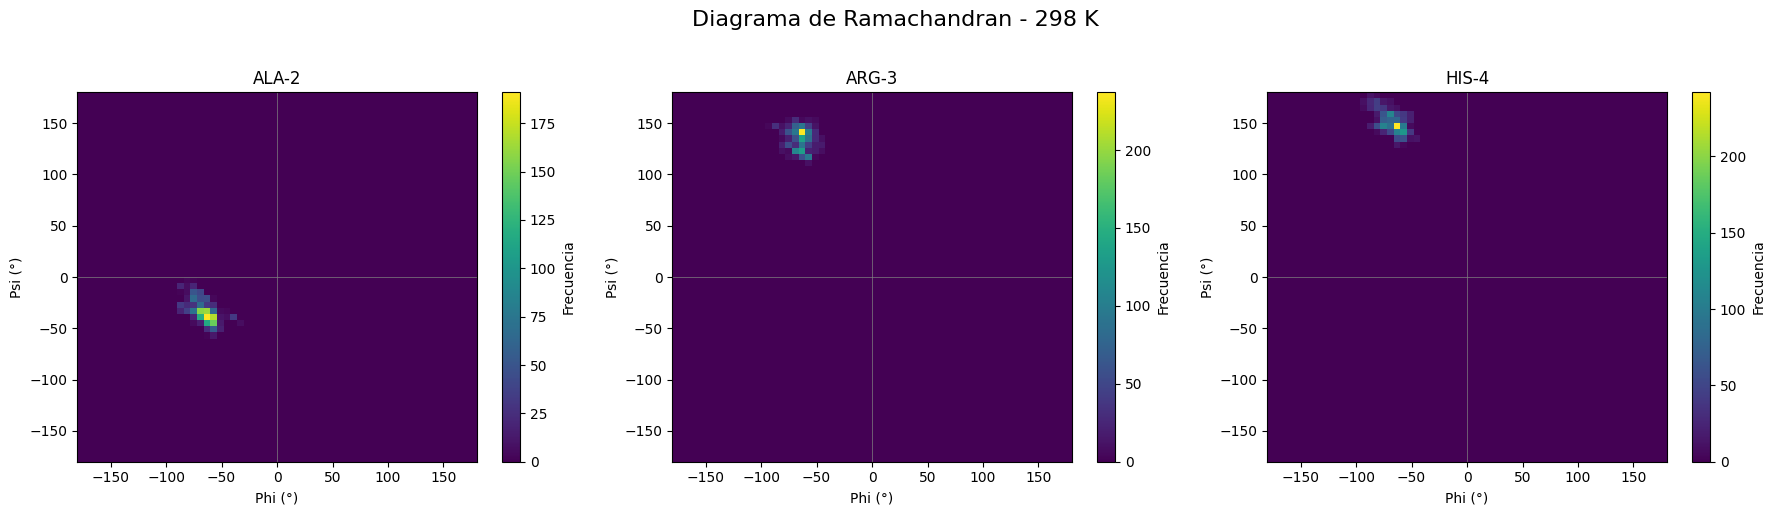

In [15]:
residuos_unicos = np.unique(residuos)
fig, axes = plt.subplots(1, len(residuos_unicos), figsize=(6*len(residuos_unicos), 5))

if len(residuos_unicos) == 1:
    axes = [axes]

for ax, res in zip(axes, residuos_unicos):
    mask = residuos == res
    h = ax.hist2d(phi[mask], psi[mask], 
                  bins=60,                    
                  range=[[-180,180],[-180,180]],
                  cmap='viridis')               
    plt.colorbar(h[3], ax=ax, label='Frecuencia')
    ax.set_xlabel('Phi (°)')
    ax.set_ylabel('Psi (°)')
    ax.set_title(f'{res}')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('Diagrama de Ramachandran - 298 K', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

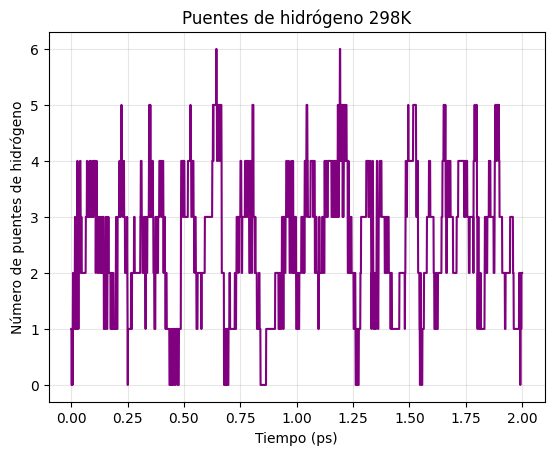

In [16]:
data3 = np.loadtxt("num.xvg", comments=['#', '@'])

plt.plot(data3[:, 0], data3[:, 1], color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Número de puentes de hidrógeno") 
plt.title("Puentes de hidrógeno 298K") 
plt.grid(alpha=0.3)
plt.show()

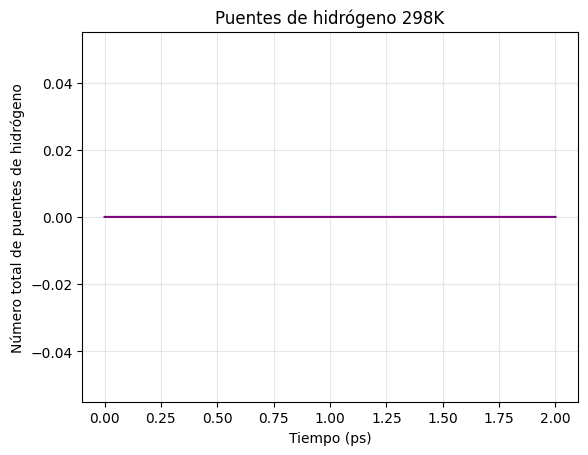

In [17]:
data4 = np.loadtxt("hx.xvg", comments=['#', '@'])

tiempo = data4[:, 0]
num_puentes = data4[:, 1:].sum(axis=1)

plt.plot(tiempo, num_puentes, color=mcolors.CSS4_COLORS['purple'], linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Número total de puentes de hidrógeno") 
plt.title("Puentes de hidrógeno 298K") 
plt.grid(alpha=0.3)
plt.show()

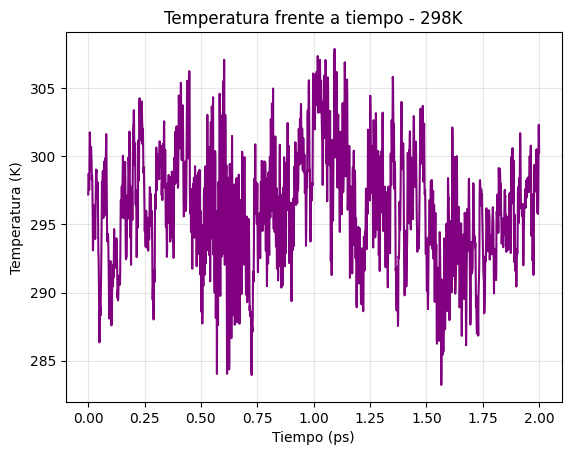

In [18]:
data4 = np.loadtxt("temp.xvg", comments=['#', '@'])

plt.plot(data4[:, 0], data4[:, 1:].sum(axis=1), 
         color=mcolors.CSS4_COLORS['purple'],  linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Temperatura (K)") 
plt.title("Temperatura frente a tiempo - 298K") 
plt.grid(alpha=0.3)
plt.show()

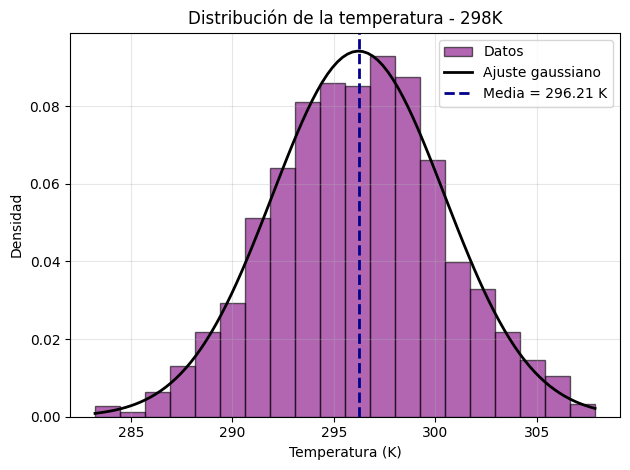

In [19]:
temp = data4[:, 1]

# Parámetros
media = np.mean(temp)
std = np.std(temp)

plt.figure()

# Histograma normalizado
count, bins, _ = plt.hist(temp, bins=20, density=True,
                          edgecolor='black', alpha=0.6,
                          label='Datos', color=mcolors.CSS4_COLORS['purple'])

# Curva gaussiana
x = np.linspace(min(temp), max(temp), 100)
gauss = (1/(std*np.sqrt(2*np.pi))) * np.exp(-(x-media)**2/(2*std**2))

plt.plot(x, gauss, linewidth=2, label='Ajuste gaussiano', color=mcolors.CSS4_COLORS['black'] )

# Media
media = np.mean(data4[:, 1])
plt.axvline(media, linestyle='--', linewidth=2, label=f'Media = {media:.2f} K',
            color=mcolors.CSS4_COLORS['darkblue'])

# Etiquetas
plt.xlabel('Temperatura (K)')
plt.ylabel('Densidad')
plt.title('Distribución de la temperatura - 298K')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

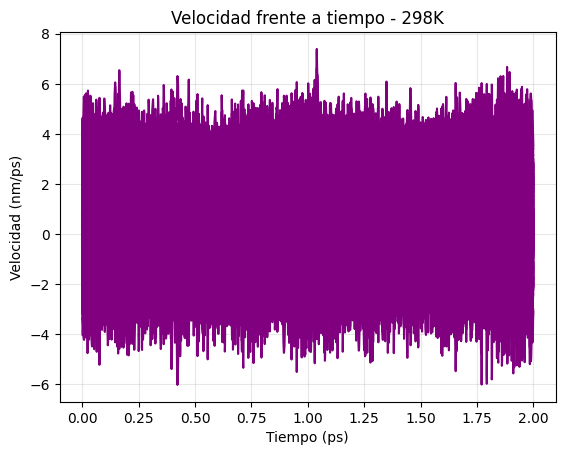

In [2]:
data4 = np.loadtxt("veloc.xvg", comments=['#', '@'])

plt.plot(data4[:, 0], data4[:, 4:], 
         color=mcolors.CSS4_COLORS['purple'],  linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Velocidad (nm/ps)") 
plt.title("Velocidad frente a tiempo - 298K") 
plt.grid(alpha=0.3)
plt.show()

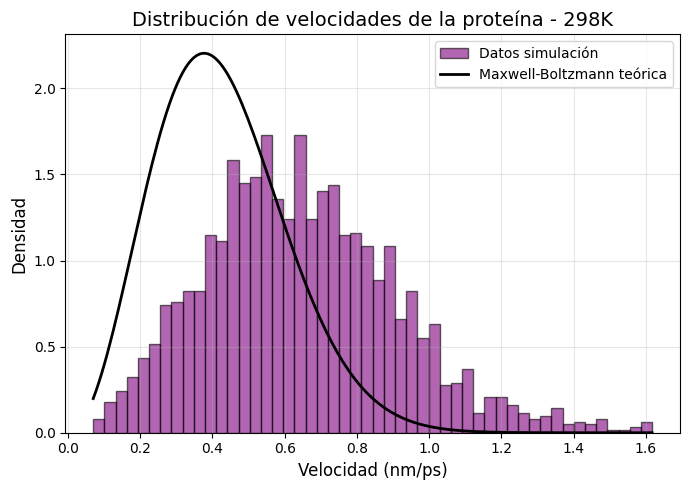

In [3]:
from scipy.stats import maxwell

# Cargar datos
data = np.loadtxt('veloc.xvg')

# Elegimos la magnitud de la velocidad (columna 5)
vel = data[:, 4]  # Python index empieza en 0

# --- Histograma ---
plt.figure(figsize=(7,5))

# Histograma normalizado para poder superponer la Maxwell-Boltzmann
count, bins, _ = plt.hist(vel, bins=50, density=True, 
                          edgecolor='black', alpha=0.6, label='Datos simulación',
                          color=mcolors.CSS4_COLORS['purple'])

# --- Curva Maxwell-Boltzmann ---
# Ajustamos la distribución usando la desviación estándar de los datos
sigma = np.std(vel)
x = np.linspace(min(vel), max(vel), 200)
plt.plot(x, maxwell.pdf(x, scale=sigma), lw=2, label='Maxwell-Boltzmann teórica',
         color=mcolors.CSS4_COLORS['black'])

# Etiquetas y título
plt.xlabel('Velocidad (nm/ps)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Distribución de velocidades de la proteína - 298K', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

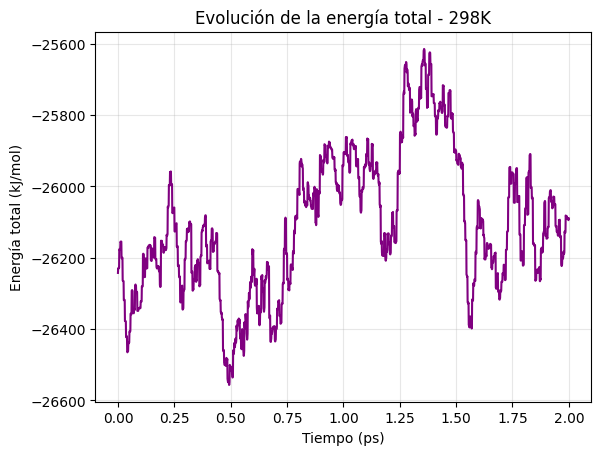

In [21]:
data4 = np.loadtxt("#energy.xvg.1#", comments=['#', '@'])

plt.plot(data4[:, 0], data4[:, 1:], 
         color=mcolors.CSS4_COLORS['purple'],  linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Energía total (kJ/mol)") 
plt.title("Evolución de la energía total - 298K") 
plt.grid(alpha=0.3)
plt.show()

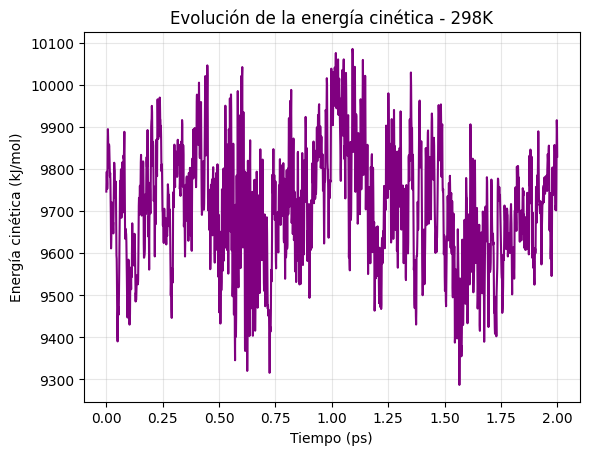

In [22]:
data4 = np.loadtxt("energy.xvg", comments=['#', '@'])

plt.plot(data4[:, 0], data4[:, 1:], 
         color=mcolors.CSS4_COLORS['purple'],  linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Energía cinética (kJ/mol)") 
plt.title("Evolución de la energía cinética - 298K") 
plt.grid(alpha=0.3)
plt.show()